In [27]:
# --- CÉLULA 1: Imports e Configuração ---
import sys
import os
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                             roc_auc_score, roc_curve, recall_score, f1_score,
                             precision_recall_curve, average_precision_score)

# Fora do Docker, MINIO_ENDPOINT precisa apontar pro host publicado
# localmente, não pro nome do serviço Docker ("minio").
os.environ["MINIO_ENDPOINT"] = "http://localhost:9000"
os.environ["AWS_ACCESS_KEY_ID"] = "minioadmin"
os.environ["AWS_SECRET_ACCESS_KEY"] = "minioadmin123"

# Localização da raiz e config
PROJECT_ROOT = Path.cwd().parent
with open(PROJECT_ROOT / "Model" / "config.yml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

sys.path.insert(0, str(PROJECT_ROOT))
from storage import get_storage

store = get_storage(cfg)

# Carrega os dados de teste do bucket "models" (não do filesystem local)
with store.open("models", "evaluation_data/X_test.pkl", "rb") as fh:
    X_test = joblib.load(fh)
with store.open("models", "evaluation_data/y_test.pkl", "rb") as fh:
    y_test = joblib.load(fh)
with store.open("models", "evaluation_data/feature_names.pkl", "rb") as fh:
    feature_names = joblib.load(fh)

resultados = []

In [28]:
# --- CÉLULA 2: Funções auxiliares ---

def carregar_modelo(store, model_name):
    model_key = f"models/{model_name}/model.pkl"
    threshold_key = f"models/{model_name}/threshold.txt"

    print(f"Carregando: {model_key}")

    with store.open("models", model_key, "rb") as fh:
        model = joblib.load(fh)

    with store.open("models", threshold_key, "r") as fh:
        threshold = float(fh.read())

    return model, threshold


def alinhar_features(model, X_test):
    if hasattr(model, "feature_names_in_"):
        features_esperadas = model.feature_names_in_

    elif hasattr(model, "named_steps") and "model" in model.named_steps:
        features_esperadas = model.named_steps["model"].feature_names_in_

    else:
        features_esperadas = X_test.columns

    X_aligned = X_test.reindex(columns=features_esperadas, fill_value=0)

    return X_aligned

In [29]:
# --- CÉLULA 3: Avaliação Dinâmica de Modelos (Corrigida) ---

print("--- Iniciando comparativo com Thresholds Otimizados ---")

model_names = [name for name, info in cfg["models"].items() if info.get("enabled", True)]

for model_name in model_names:
    model, threshold = carregar_modelo(store, model_name)
    X_aligned = alinhar_features(model, X_test)

    # 3. Predição e Métricas
    probs = model.predict_proba(X_aligned)[:, 1]
    y_pred = (probs >= threshold).astype(int)

    auc = roc_auc_score(y_test, probs)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    resultados.append({
       'Modelo': model_name,
       'ROC AUC': auc,
       'Acurácia': acc,
       'Precisão': prec,
       'Recall': recall,
       'F1': f1,
       'Threshold': threshold
    })

# --- PROTEÇÃO CONTRA O KEYERROR ---
if resultados:
    df_resumo = pd.DataFrame(resultados)
    df_resumo = df_resumo.sort_values(by='ROC AUC', ascending=False)
    display(df_resumo)
else:
    print("ERRO: Nenhuma métrica foi coletada. Verifique se o bucket 'models' no MinIO tem model.pkl e threshold.txt para cada modelo em cfg['models'].")

--- Iniciando comparativo com Thresholds Otimizados ---
Carregando: models/XGBOOST/model.pkl
Carregando: models/RANDOM_FOREST/model.pkl


c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Carregando: models/LOGISTIC_REGRESSION/model.pkl


c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.4.0 when using version 1.9.0. This might 

,Modelo,ROC AUC,Acurácia,Precisão,Recall,F1,Threshold
0,XGBOOST,0.771762,0.601470,0.144734,0.801826,0.245206,0.349982
2,LOGISTIC_REGRESSION,0.760172,0.489431,0.122960,0.868153,0.215411,0.349969
1,RANDOM_FOREST,0.747318,0.741280,0.179997,0.620032,0.279000,0.100000


Carregando: models/XGBOOST/model.pkl
Carregando: models/LOGISTIC_REGRESSION/model.pkl


c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.4.0 when using version 1.9.0. This might 

Carregando: models/RANDOM_FOREST/model.pkl


c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


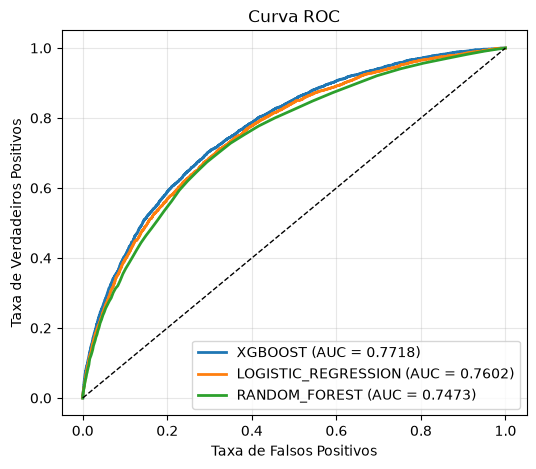

In [30]:
# --- CÉLULA 4: Comparação entre células método AUC/ROC--
plt.figure(figsize=(6, 5))
for model_name in df_resumo["Modelo"]:
    model, threshold = carregar_modelo(store, model_name)
    X_aligned = alinhar_features(model, X_test)

    # Predição
    probs = model.predict_proba(X_aligned)[:, 1]

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})', lw=2)

plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title(f'Curva ROC')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

Carregando: models/XGBOOST/model.pkl


Carregando: models/LOGISTIC_REGRESSION/model.pkl


c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.4.0 when using version 1.9.0. This might 

Carregando: models/RANDOM_FOREST/model.pkl


c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


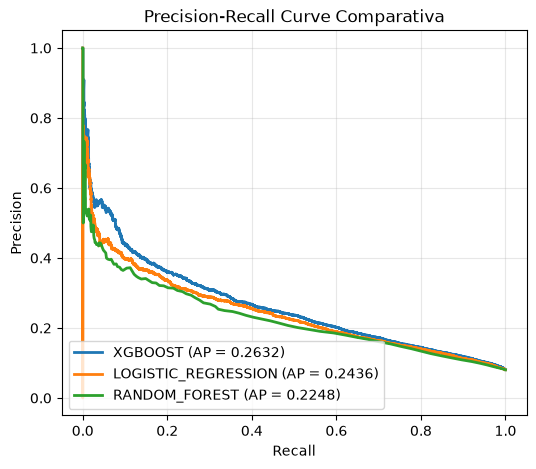

In [31]:
# --- CÉLULA 5: Precision-Recall Curve comparativa ---

plt.figure(figsize=(6, 5))
for model_name in df_resumo ["Modelo"]:
    model, threshold = carregar_modelo(store, model_name)
    X_aligned = alinhar_features (model, X_test)

    # Predição
    probs = model.predict_proba(X_aligned)[:, 1]

    # Precision x Recall
    precision, recall, threshold = precision_recall_curve(y_test, probs)
    ap_score = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f'{model_name} (AP = {ap_score:.4f})', lw=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve Comparativa')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()


Carregando: models/XGBOOST/model.pkl


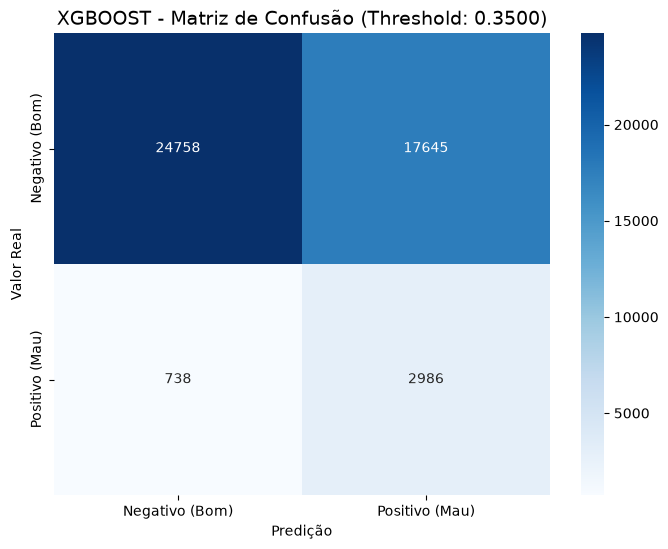

Carregando: models/LOGISTIC_REGRESSION/model.pkl


c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.4.0 when using version 1.9.0. This might 

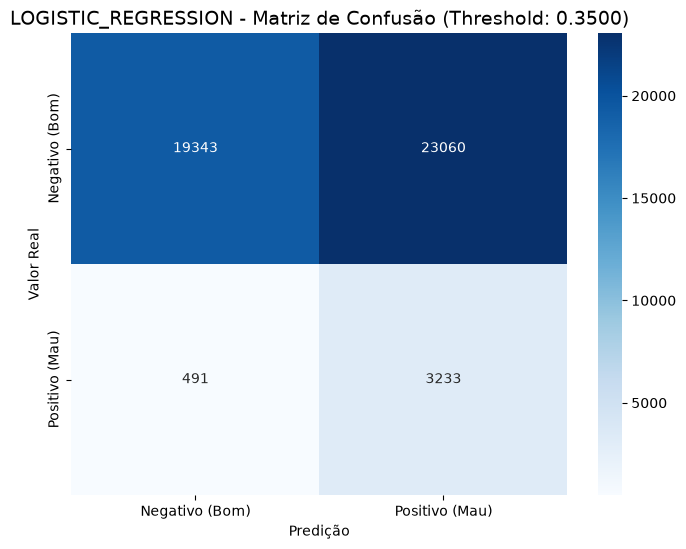

Carregando: models/RANDOM_FOREST/model.pkl


c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


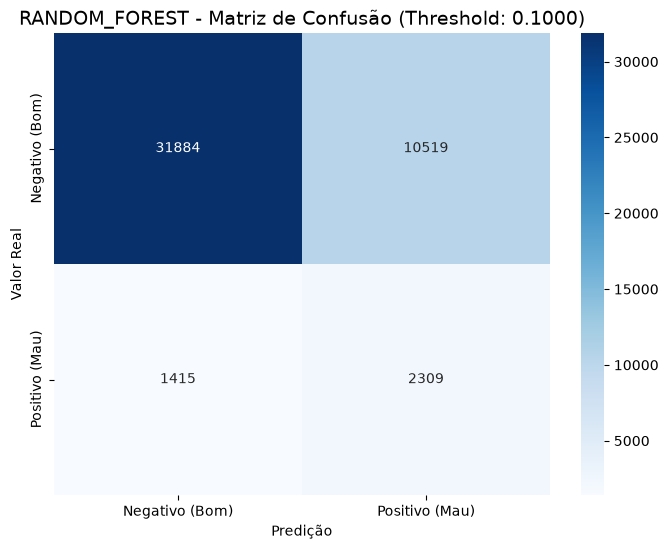

In [32]:
# --- CÉLULA 6: Matriz de Confusão ---

for model_name in df_resumo ["Modelo"]:
    model, threshold = carregar_modelo(store, model_name)
    X_aligned = alinhar_features (model, X_test)

    # Predição
    probs = model.predict_proba(X_aligned)[:, 1]
    y_pred = (probs >= threshold).astype(int)

    # plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), 
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negativo (Bom)', 'Positivo (Mau)'], 
                yticklabels=['Negativo (Bom)', 'Positivo (Mau)'])

    plt.title(f'{model_name} - Matriz de Confusão (Threshold: {threshold:.4f})', fontsize=14)
    plt.xlabel('Predição')
    plt.ylabel('Valor Real')
    plt.show()

In [33]:
# --- CÉLULA 7: Investigação de Viés por Fontes Externas ---
# Vamos comparar o EXT_SOURCE_2 (que geralmente é muito forte) 
# entre os Falsos Positivos e o resto da base.

fp_indices = (y_test == 0) & (y_pred == 1)
df_fp = X_test[fp_indices]
df_outros = X_test[~fp_indices]

print("--- Comparação de Fontes Externas ---")
print(f"Média EXT_SOURCE_2 nos Falsos Positivos: {df_fp['EXT_SOURCE_2'].mean():.4f}")
print(f"Média EXT_SOURCE_2 no restante da base: {df_outros['EXT_SOURCE_2'].mean():.4f}")

# Dica: Se a média dos FP for muito baixa, o modelo está "viciado" 
# em reprovar quem tem score baixo nessas fontes, ignorando que o DTI é bom.

--- Comparação de Fontes Externas ---
Média EXT_SOURCE_2 nos Falsos Positivos: 0.3805
Média EXT_SOURCE_2 no restante da base: 0.5542


Carregando: models/XGBOOST/model.pkl


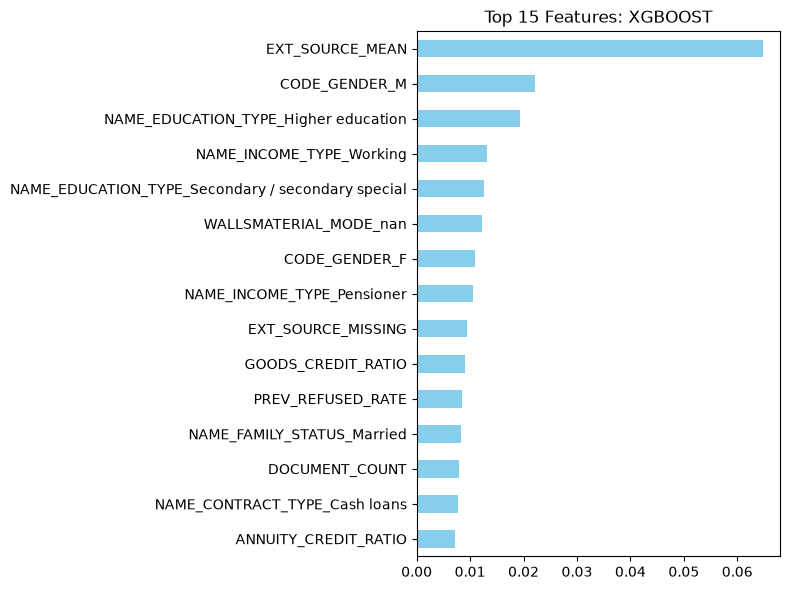

Carregando: models/LOGISTIC_REGRESSION/model.pkl


c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.4.0 when using version 1.9.0. This might 

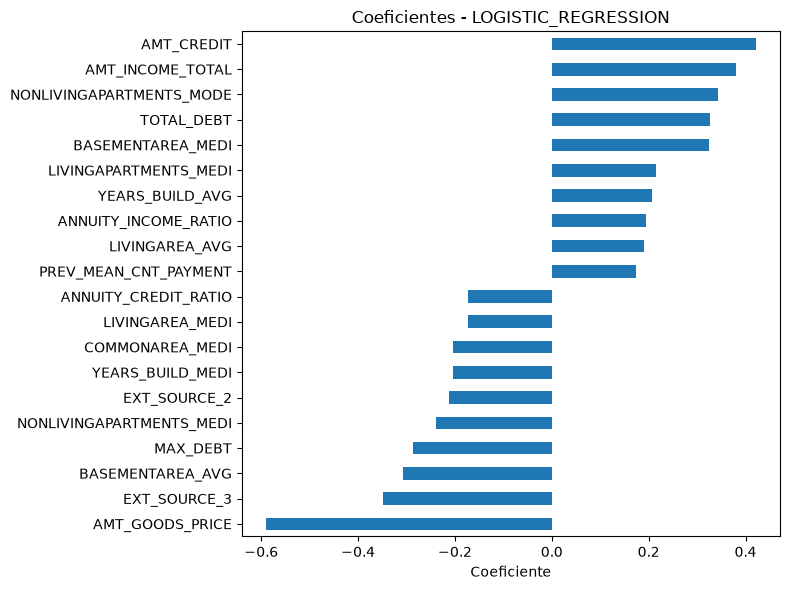

Carregando: models/RANDOM_FOREST/model.pkl


c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Alex\projeto_ml\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.4.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


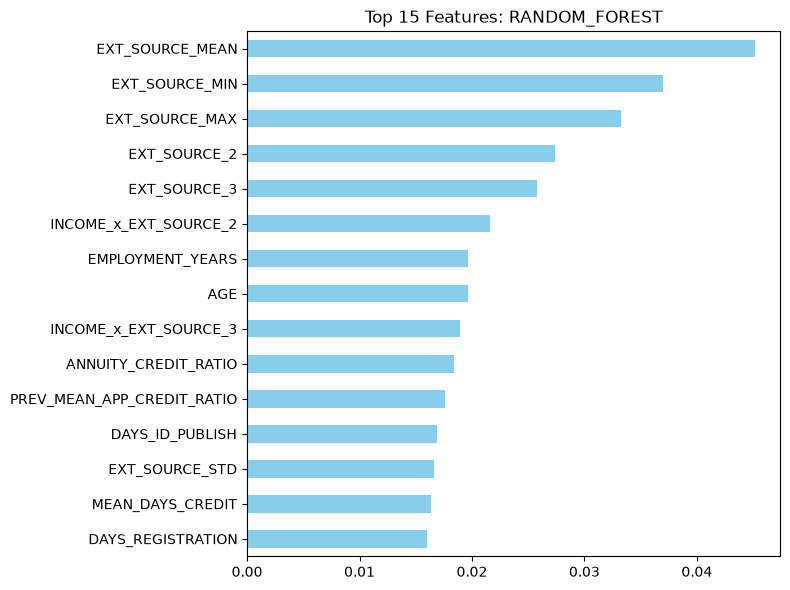

In [34]:
# --- CÉLULA 8: interpretabilidade específica ---

for model_name in df_resumo ["Modelo"]:
    model, threshold = carregar_modelo(store, model_name)
    est = model.named_steps['model'] if isinstance(model, Pipeline) else model
    if model_name in ["XGBOOST","RANDOM_FOREST"]:
        if hasattr(est, 'feature_importances_'):
            imp = pd.Series(est.feature_importances_, index=feature_names).nlargest(15)
            plt.figure(figsize=(8, 6))
            imp.sort_values().plot(kind='barh', color='skyblue')
            plt.title(f'Top 15 Features: {model_name}')
            plt.tight_layout()
            plt.show()
            plt.close()

    else:       
        if hasattr(est, 'coef_'):
            coef = pd.Series(est.coef_[0], index=feature_names)

            top_positivos = coef.nlargest(10)
            top_negativos = coef.nsmallest(10)

            coef_plot = pd.concat([top_negativos, top_positivos])

            plt.figure(figsize=(8, 6))
            coef_plot.sort_values().plot(kind="barh")
            plt.title(f"Coeficientes - {model_name}")
            plt.xlabel("Coeficiente")
            plt.tight_layout()
            plt.show()
            plt.close()


In [35]:
# --- CÉLULA 9: Conclusão ---
display(df_resumo)
best_model = df_resumo.iloc[0]
# Extrair principais métricas
nome_modelo = best_model["Modelo"]
roc_auc = best_model["ROC AUC"]
acuracia = best_model["Acurácia"]
precisao = best_model["Precisão"]
recall = best_model["Recall"]
f1 = best_model["F1"]
threshold = best_model["Threshold"]
#Exibir resumo do modelo campeão
print("=== Modelo Campeão ===")
print(f"Modelo: {best_model}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Threshold: {threshold:.4f}")
#Texto final interpretativo
print("\n=== Conclusão ===")
print(
    f"O modelo com melhor desempenho geral foi o {best_model}, "
    f"apresentando ROC AUC de {roc_auc:.4f}. "
    "A escolha considera principalmente a capacidade de separação entre bons e maus pagadores, "
    "além do equilíbrio observado entre precisão, recall e F1-score."
)

,Modelo,ROC AUC,Acurácia,Precisão,Recall,F1,Threshold
0,XGBOOST,0.771762,0.601470,0.144734,0.801826,0.245206,0.349982
2,LOGISTIC_REGRESSION,0.760172,0.489431,0.122960,0.868153,0.215411,0.349969
1,RANDOM_FOREST,0.747318,0.741280,0.179997,0.620032,0.279000,0.100000


=== Modelo Campeão ===
Modelo: Modelo        XGBOOST
ROC AUC      0.771762
Acurácia      0.60147
Precisão     0.144734
Recall       0.801826
F1           0.245206
Threshold    0.349982
Name: 0, dtype: object
ROC AUC: 0.7718
Acurácia: 0.6015
Precisão: 0.1447
Recall: 0.8018
F1-score: 0.2452
Threshold: 0.3500

=== Conclusão ===
O modelo com melhor desempenho geral foi o Modelo        XGBOOST
ROC AUC      0.771762
Acurácia      0.60147
Precisão     0.144734
Recall       0.801826
F1           0.245206
Threshold    0.349982
Name: 0, dtype: object, apresentando ROC AUC de 0.7718. A escolha considera principalmente a capacidade de separação entre bons e maus pagadores, além do equilíbrio observado entre precisão, recall e F1-score.


In [36]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb

# Configuração do K-Fold estratificado (essencial devido aos 8% de inadimplentes)
# O StratifiedKFold garante que a proporção de 8% de inadimplentes se mantenha em todos os folds
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Instancie seu modelo (o mesmo que vocês definiram no projeto)
model = xgb.XGBClassifier(scale_pos_weight=11) # Exemplo baseado no seu scale_pos_weight

with store.open("models", "evaluation_data/X_train.pkl", "rb") as fh:
    X_train = joblib.load(fh)
with store.open("models", "evaluation_data/y_train.pkl", "rb") as fh:
    y_train = joblib.load(fh)

# Executa a validação cruzada
scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"AUCs por Fold: {scores}")
print(f"AUC Médio: {scores.mean():.4f} (+/- {scores.std():.4f})")

AUCs por Fold: [0.75243919 0.75724946 0.75394514 0.75721535 0.75087255 0.75287952
 0.75893833 0.75761733 0.74994801 0.74753251]
AUC Médio: 0.7539 (+/- 0.0036)


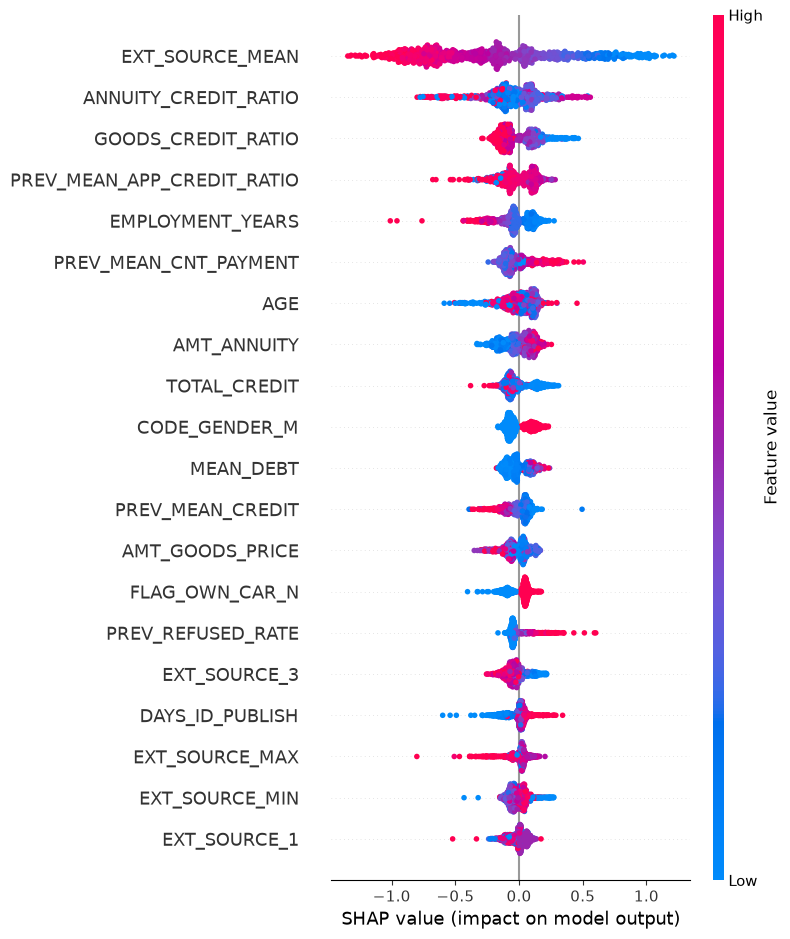

In [37]:
import shap

# 1. Cria o objeto explicador para o modelo XGBoost
with store.open("models", "models/XGBOOST/model.pkl", "rb") as fh:
    model = joblib.load(fh)
explainer = shap.TreeExplainer(model)

# 2. Calcula os valores SHAP para uma amostra dos dados (ex: primeiras 1000 linhas)
# Usar uma amostra acelera o processamento em bases grandes como a da Home Credit 
shap_values = explainer.shap_values(X_train.iloc[:1000])

# 3. Gráfico de Resumo (Substitui ou complementa a Feature Importance) 
# Mostra o impacto global e a direção (se a variável aumenta ou diminui o risco)
shap.summary_plot(shap_values, X_train.iloc[:1000])